In [1]:
import numpy as np
import pandas as pd
data = np.load("../data/c_a/processed/dataset_full.npz", allow_pickle=True)
X_full = data["X"]
df = pd.DataFrame(X_full, columns=[f"F{i}" for i in range(30)])


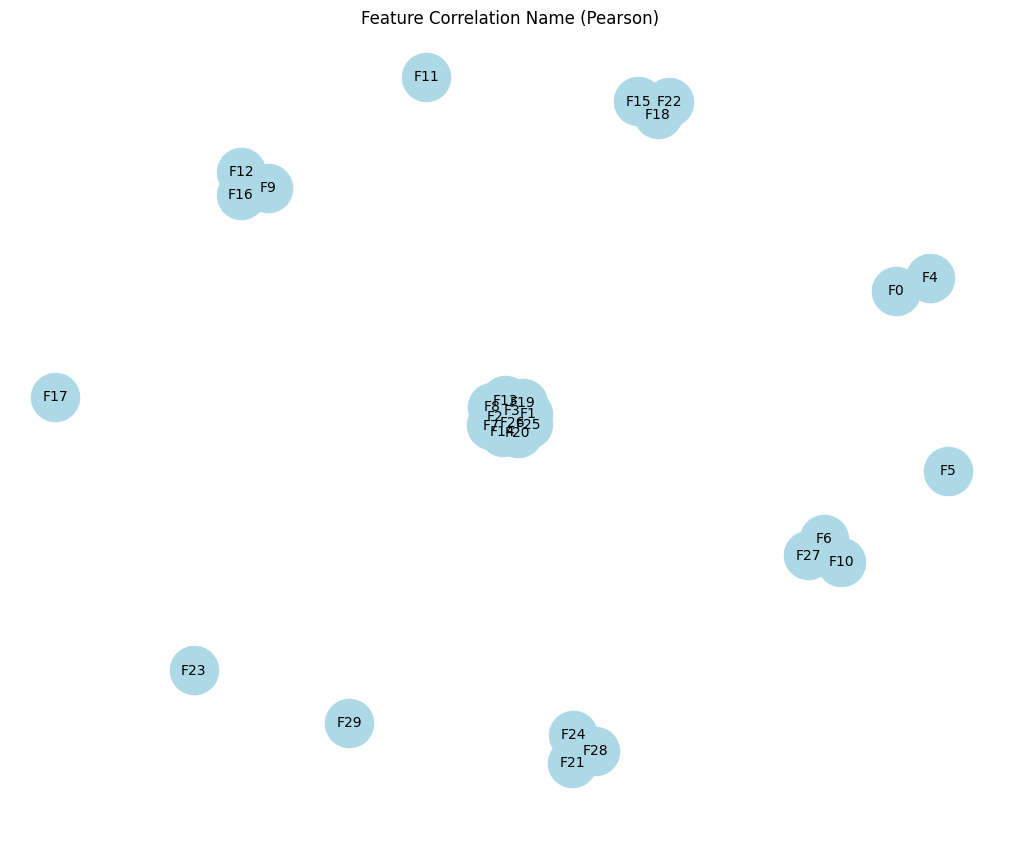

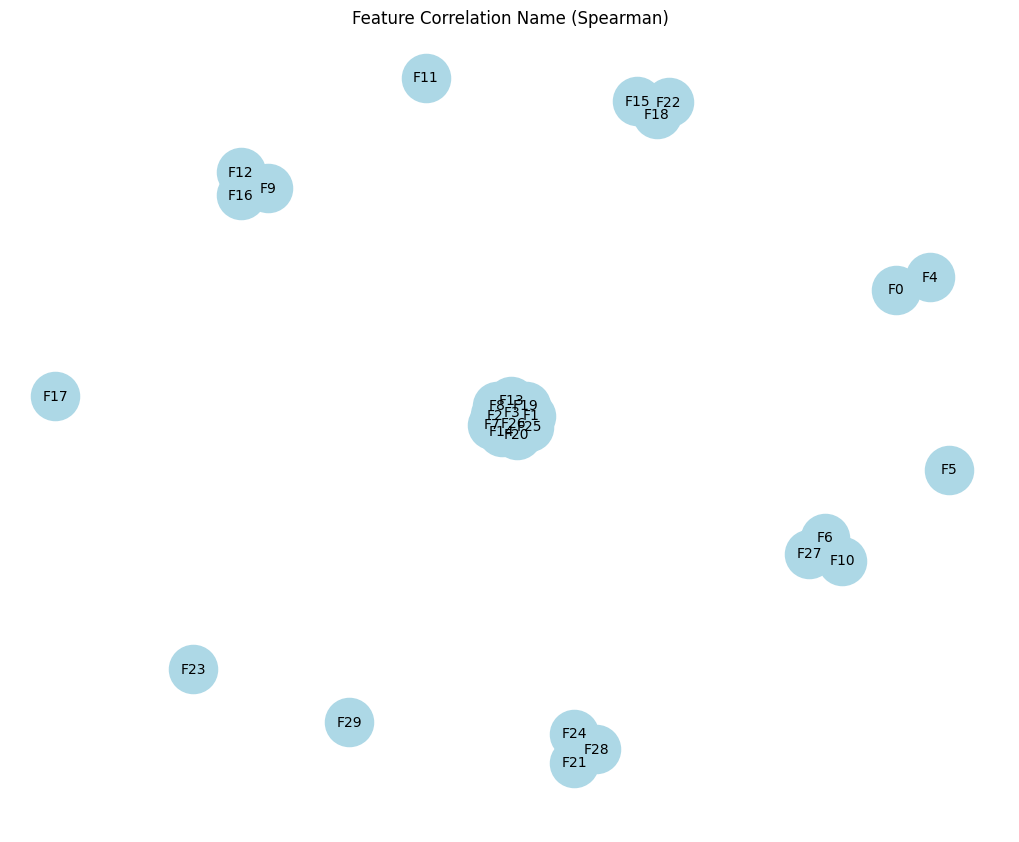

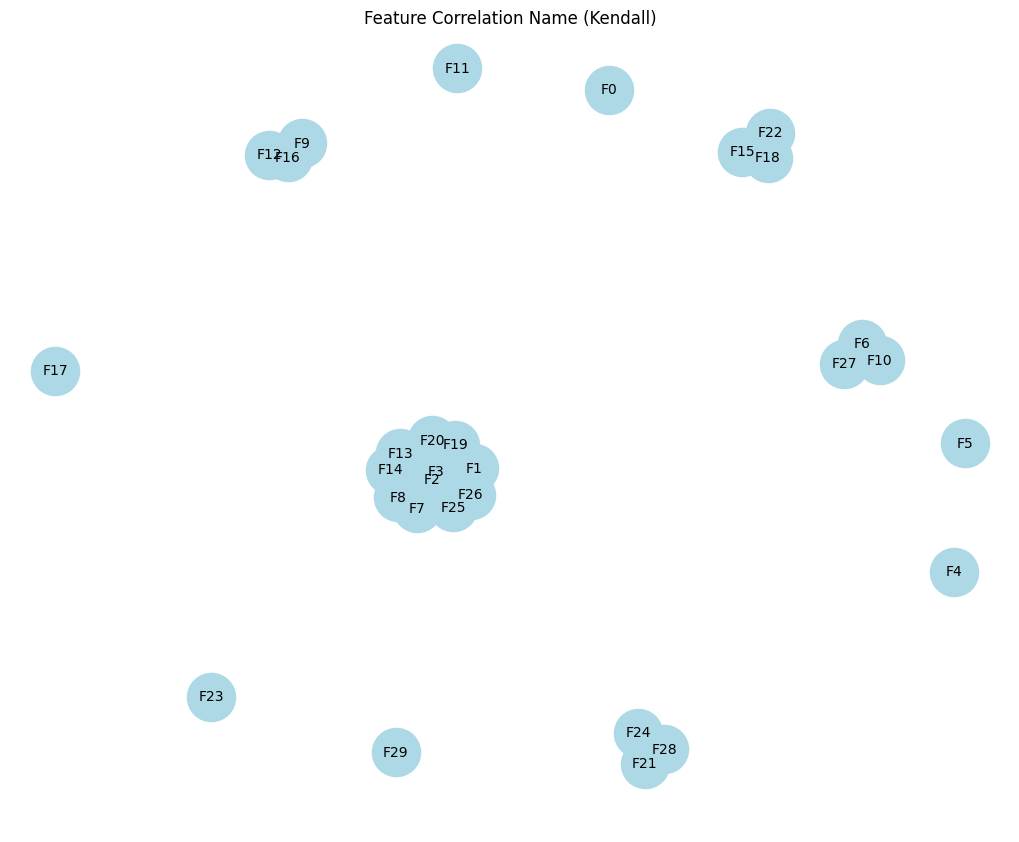

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

corr_methods = {
    "Pearson": df.corr().abs(),
    "Spearman": df.corr(method="spearman").abs(),
    "Kendall": df.corr(method="kendall").abs()
}
threshold = 0.8

G = nx.Graph()

for name, corr in corr_methods.items():
    G = nx.Graph()

    for col in df.columns:
        G.add_node(col)
        
    for i in range(len(df.columns)):
        for j in range(i+1, len(df.columns)):
            if corr.iloc[i,j] > threshold:
                G.add_edge(
                    df.columns[i],
                    df.columns[j],
                    weight=corr.iloc[i, j]
                )

    plt.figure(figsize=(10,8))
    pos = nx.spring_layout(G, seed=0)
    edges = G.edges(data=True)
    weights = [d.get("weight",1) * 3 for (_,_,d) in edges]

    nx.draw(
        G,
        pos,
        with_labels=True,
        width=weights,
        node_size=1200,
        node_color="lightblue",
        font_size=10
    )
    plt.title(f"Feature Correlation Name ({name})")
    plt.show()

  